<a href="https://colab.research.google.com/github/melissa-std/Ontologie_Tourisme_SII_2025-2025/blob/main/TP2_VisioArtificielle_py.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **PARTIE 1 — Segmentation des caractères manuscrits**

# 1.**Chargement** de **l’image**:




In [ ]:
import cv2
img = cv2.imread('/MnistExamples.png')
print(img)

[[[255 255 255]
  [255 255 255]
  [255 255 255]
  ...
  [255 255 255]
  [255 255 255]
  [255 255 255]]

 [[255 255 255]
  [255 255 255]
  [255 255 255]
  ...
  [255 255 255]
  [255 255 255]
  [255 255 255]]

 [[255 255 255]
  [255 255 255]
  [255 255 255]
  ...
  [255 255 255]
  [255 255 255]
  [255 255 255]]

 ...

 [[255 255 255]
  [255 255 255]
  [255 255 255]
  ...
  [255 255 255]
  [255 255 255]
  [255 255 255]]

 [[255 255 255]
  [255 255 255]
  [255 255 255]
  ...
  [255 255 255]
  [255 255 255]
  [255 255 255]]

 [[255 255 255]
  [255 255 255]
  [255 255 255]
  ...
  [255 255 255]
  [255 255 255]
  [255 255 255]]]


# **Convertir en niveau de gris :**

In [ ]:
if img is not None:
    gray = cv2.cvtColor(img,cv2.COLOR_BGR2GRAY)
else:
    print("Error: L'image 'img' n'a pas été chargée correctement. Veuillez vérifier le chemin de l'image ou l'existence du fichier.")
    gray = None # Assign None or handle the error gracefully

# **2.Binariser l’image (chiffres blancs / fond noir)**


In [ ]:
_, binary1 = cv2.threshold(gray, 0, 255, cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU)

# Fonction Global :

In [ ]:
def load_bin(path):
  img = cv2.imread(path)
  gray = cv2.cvtColor(img,cv2.COLOR_BGR2GRAY)
  _,binary = cv2.threshold(gray,0,255,cv2.THRESH_BINARY_INV+cv2.THRESH_OTSU)
  return binary

# Projection horizental

In [ ]:
import numpy as np

# *Segmentation des images : *

In [ ]:
def segmentation(binary):
    lines = []
    inline = False
    start = 0
    all_characters = [] # Liste pour stocker chaque chiffre individuel
    #projection horizental de l'image
    proj_h = np.sum(binary > 0, axis=1)
    # 1. Détection des lignes
    for i in range(len(proj_h)):
        if proj_h[i] > 0 and not inline:
            start = i
            inline = True
        elif proj_h[i] == 0 and inline:
            end = i
            lines.append((start, end))
            inline = False
    if inline:
        lines.append((start, len(proj_h)))

    # 2. Pour chaque ligne, on découpe les caractères
    for y_start, y_end in lines:
        line_img = binary[y_start:y_end, :] # Découpe de la ligne

        # Calcul de la projection verticale sur cette ligne
        proj_v = np.sum(line_img, axis=0)

        in_char = False
        c_start = 0

        for j in range(len(proj_v)):
            if proj_v[j] > 0 and not in_char:
                c_start = j
                in_char = True
            elif proj_v[j] == 0 and in_char:
                # Découpage du caractère
                char_img = line_img[:, c_start:j] #toute la hauteur
                all_characters.append(char_img)
                in_char = False

        # Cas où le dernier caractère touche le bord droit
        if in_char:
            all_characters.append(line_img[:, c_start:len(proj_v)])

    return all_characters # Retourne la liste de tous les chiffres trouvés

# Normalization

In [ ]:
def normalize_to_minsit(char_image):
  h,w = char_image.shape
  if h >w :
    new_h = 20
    new_w = int((20*w)/h)
  else :
    new_w = 20
    new_h = int((20*h)/w)
  resized = cv2.resize(char_image,(new_w,new_h)) # Corrected: swapped new_h and new_w
  #creer une image noir pour mettre le chiffre dedans pour que ca soit 28*28
  new_img = np.zeros((28,28),dtype=np.uint8)
  #centrer le chiffre :
  y_offset = (28-new_h)//2
  x_offset = (28-new_w)//2
  new_img[y_offset:y_offset+new_h,x_offset:x_offset+new_w] = resized
  return new_img

# Tester et voir les resultat de la première partie:

In [ ]:
import matplotlib.pyplot as plt

In [ ]:
binary = load_bin('/MnistExamples.png')
chars = segmentation(binary)
normalized_chars = [normalize_to_minsit(c) for c in chars]

# **Afficher l'image : **

### Avant segmentation :

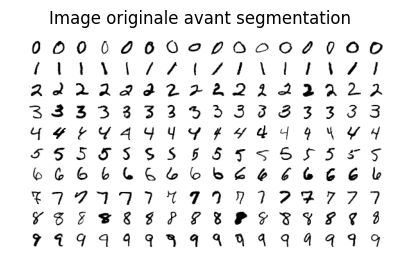

In [ ]:
plt.figure(figsize=(10,3))
plt.imshow(img, cmap='gray')  # 'gray' pour niveaux de gris
plt.title("Image originale avant segmentation")
plt.axis('off')  # supprimer les axes
plt.show()

### Aprés binarisation :

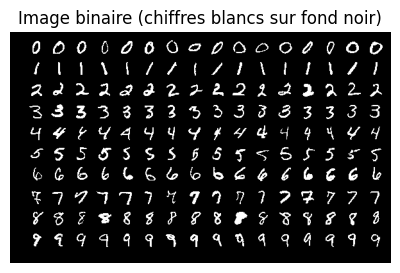

In [ ]:
plt.figure(figsize=(10,3))
plt.imshow(binary, cmap='gray')
plt.title("Image binaire (chiffres blancs sur fond noir)")
plt.axis('off')
plt.show()


### Aprés normalisation:


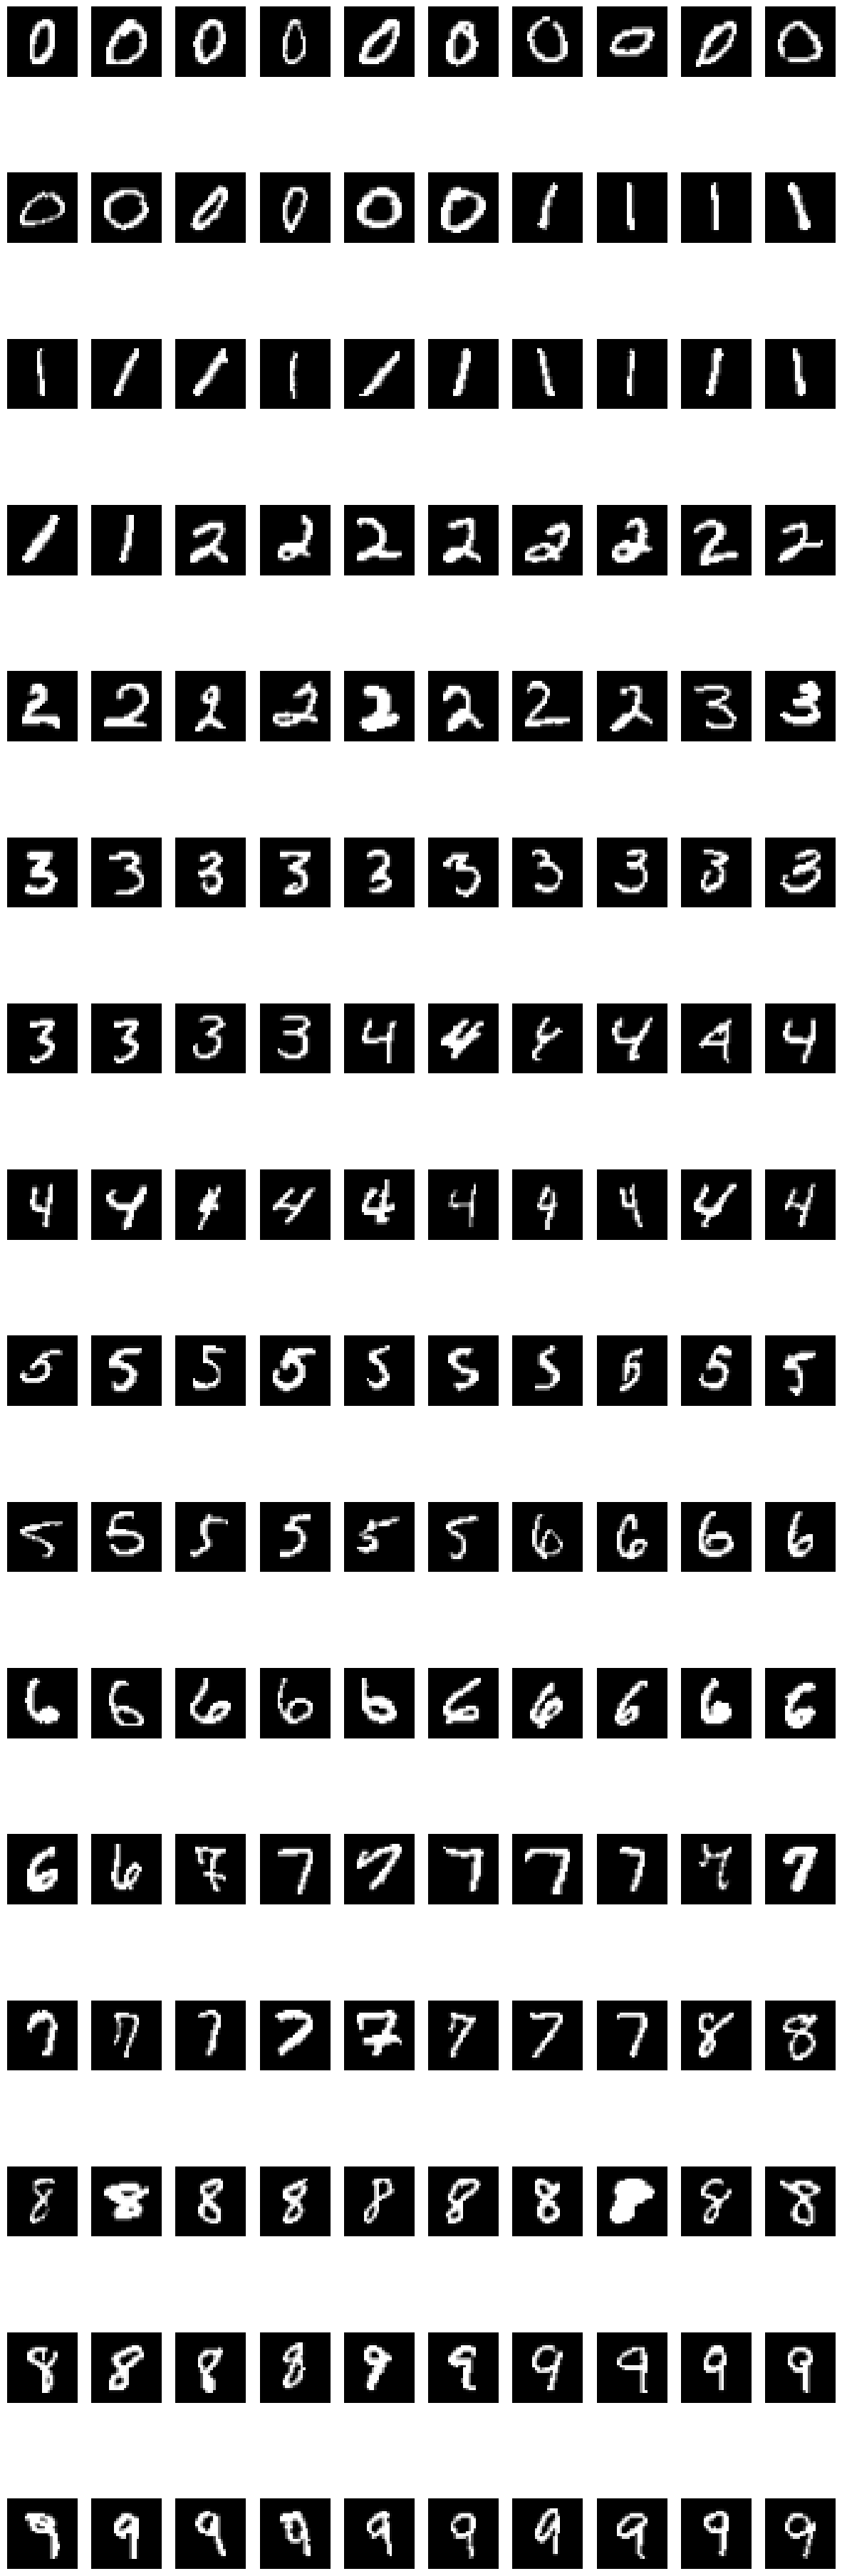

In [ ]:
n = len(normalized_chars)
cols = 10
rows = (n // cols) + 1

plt.figure(figsize=(15, 3*rows))

for i, c in enumerate(normalized_chars):
    plt.subplot(rows, cols, i+1)
    plt.imshow(c, cmap='gray')
    plt.axis('off')

plt.show()

# **Partie_02 : Prediction avec KNN**

In [ ]:
from tensorflow.keras.datasets import mnist
#chargement de données
(X_train, y_train), (X_test, y_test) = mnist.load_data()


In [ ]:
#préparation de données
X_train = X_train.reshape(X_train.shape[0], 28*28)
X_test  = X_test.reshape(X_test.shape[0], 28*28)
X_train = X_train / 255.0
X_test  = X_test / 255.0



In [ ]:
from sklearn.decomposition import PCA
pca = PCA(n_components=50)
X_train_pca = pca.fit_transform(X_train)
X_test_pca=pca.transform(X_test)



In [ ]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score

knn = KNeighborsClassifier(n_neighbors=3,metric='euclidean')
knn.fit(X_train_pca,y_train)


#calcul de performance puisque le dataset est déja séparer
y_pred = knn.predict(X_test_pca)
accuracy = accuracy_score(y_test, y_pred)

print(f"Précision du modèle : {accuracy * 100:.2f}%")

Précision du modèle : 97.52%


In [ ]:
import pickle
#sauvegarde du modèle
with open("knn_mnist_model.pkl", "wb") as f:
    pickle.dump(knn, f)
with open("pca_mnist_model.pkl", "wb") as f:
    pickle.dump(pca, f)


PHASE DE RECONNAISSANCE DE CARACTERES

In [ ]:
#chargement de nouvelle image
img_test= load_bin('/img.jpg')
chars=segmentation(img_test)
normalized_chars = [normalize_to_minsit(c) for c in chars]


In [ ]:
with open("pca_mnist_model.pkl", "rb") as f:
    pca = pickle.load(f)

with open("knn_mnist_model.pkl", "rb") as f:
    knn = pickle.load(f)
resultat=''
for char_img in normalized_chars:
  vecteur = char_img.reshape(1,28*28)
  vecteur = vecteur / 255.0
  vecteur_pca = pca.transform(vecteur)
  prediction= knn.predict(vecteur_pca)[0]
  resultat += str(prediction)
print("Séquence reconnue :", resultat)


Séquence reconnue : 01234561845


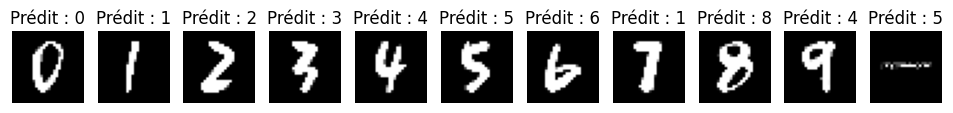

In [ ]:
#Analyse des résultats
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 3))

for i, char_img in enumerate(normalized_chars):
    vecteur = char_img.reshape(1, 28*28) / 255.0
    vecteur_pca = pca.transform(vecteur)
    pred = knn.predict(vecteur_pca)[0]

    plt.subplot(1, len(normalized_chars), i+1)
    plt.imshow(char_img, cmap='gray')
    plt.title(f"Prédit : {pred}")
    plt.axis('off')

plt.show()


In [ ]:
! pip install streamlit -q


In [ ]:
!wget -q -O - ipv4.icanhazip.com

34.173.227.246


In [ ]:
! streamlit run app.py& npx localtunnel --port

/bin/bash: line 1: streamlit: command not found
⠙⠹⠸⠼⠴⠦⠧⠇⠏⠋⠙⠹⠸⠼⠴⠦⠧⠇⠏⠋⠙Need to install the following packages:
localtunnel@2.0.2
Ok to proceed? (y) y

⠙⠹⠸⠼⠴⠦⠧⠇⠏⠋⠙⠹⠸⠼⠴⠦⠧⠇⠏⠋⠙⠹⠸⠼⠴⠦⠧⠇⠏⠋⠙your url is: https://rotten-clocks-knock.loca.lt
105.103.146.188
105.103.146.188
